In [31]:
# ============================================================================
# Part 1: Import Libraries and Load Data
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Load customer data
customers_df = pd.read_csv('Mall_Customers.csv')

print("="*60)
print("Customer Data Overview")
print("="*60)
print(f"Total Customers: {len(customers_df)}")
print(f"Number of Features: {len(customers_df.columns)}")
print(f"\nAvailable Features: {list(customers_df.columns)}")
print("\nFirst 10 Customers:")
print(customers_df.head(10))


Customer Data Overview
Total Customers: 200
Number of Features: 5

Available Features: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

First 10 Customers:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
5           6  Female   22                  17                      76
6           7  Female   35                  18                       6
7           8  Female   23                  18                      94
8           9    Male   64                  19                       3
9          10  Female   30                  19                      72


In [32]:

# ============================================================================
# Part 2: Exploratory Data Analysis (EDA)
# ============================================================================
print("\n" + "="*60)
print("Exploratory Data Analysis")
print("="*60)

# Basic dataset information
print("Dataset Information:")
print(customers_df.info())

# Statistical summary
print("\nStatistical Summary:")
print(customers_df.describe())

# Check for missing values
print("\nMissing Values Check:")
missing_values = customers_df.isnull().sum()
print(missing_values)



Exploratory Data Analysis
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Statistical Summary:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000        

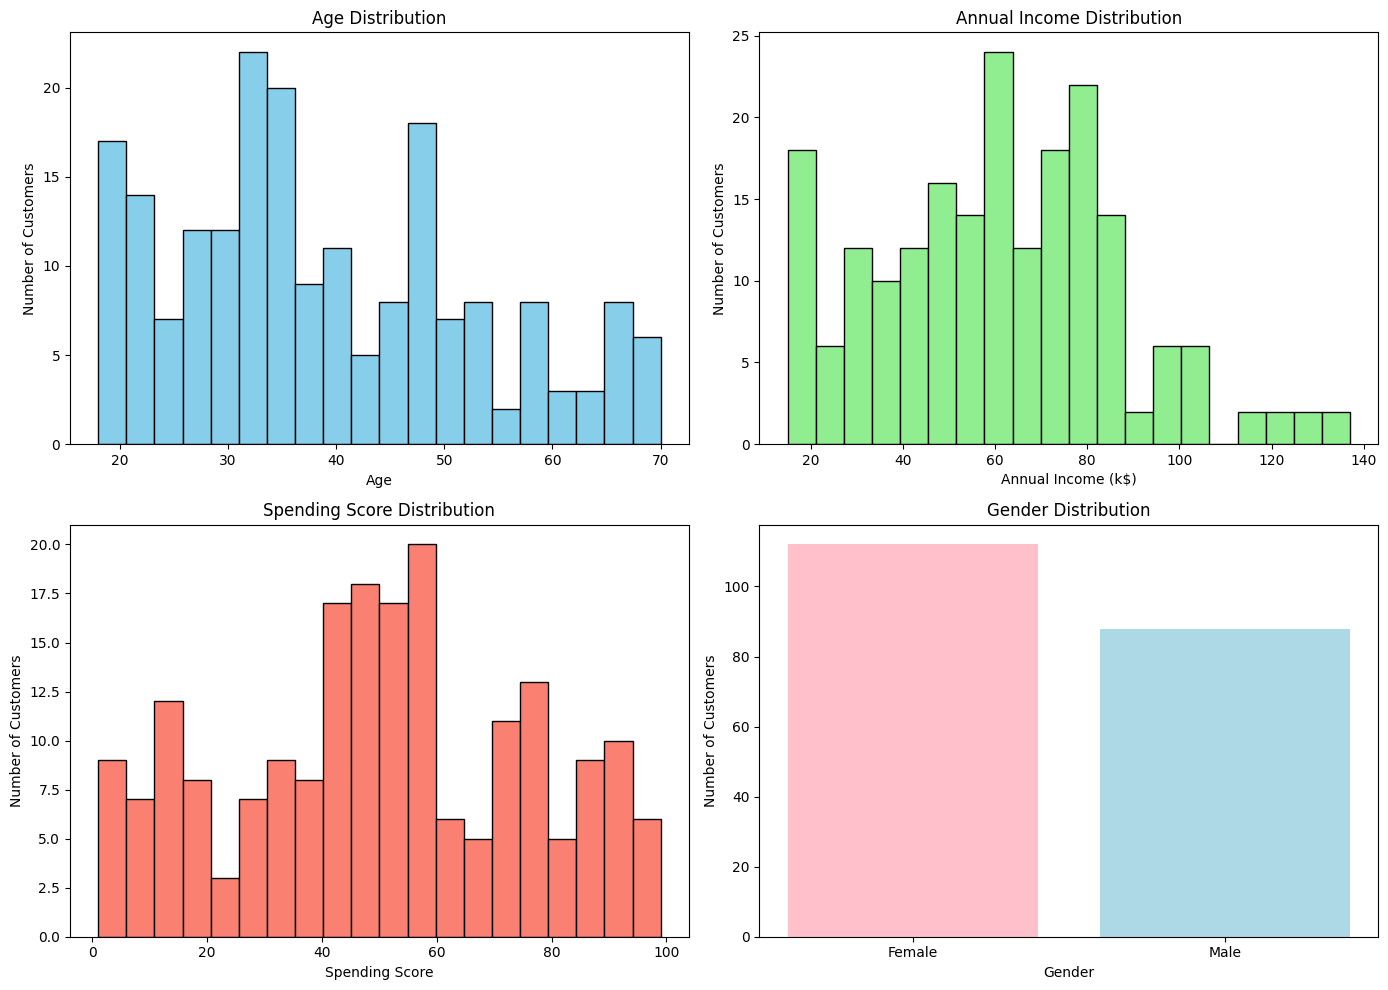

In [33]:

# ============================================================================
# Part 3: Data Visualization
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution
axes[0, 0].hist(customers_df['Age'], bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Number of Customers')

# Annual Income distribution
axes[0, 1].hist(customers_df['Annual Income (k$)'], bins=20, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Annual Income Distribution')
axes[0, 1].set_xlabel('Annual Income (k$)')
axes[0, 1].set_ylabel('Number of Customers')

# Spending Score distribution
axes[1, 0].hist(customers_df['Spending Score (1-100)'], bins=20, color='salmon', edgecolor='black')
axes[1, 0].set_title('Spending Score Distribution')
axes[1, 0].set_xlabel('Spending Score')
axes[1, 0].set_ylabel('Number of Customers')

# Gender distribution
gender_counts = customers_df['Gender'].value_counts()
axes[1, 1].bar(gender_counts.index, gender_counts.values, color=['pink', 'lightblue'])
axes[1, 1].set_title('Gender Distribution')
axes[1, 1].set_xlabel('Gender')
axes[1, 1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()


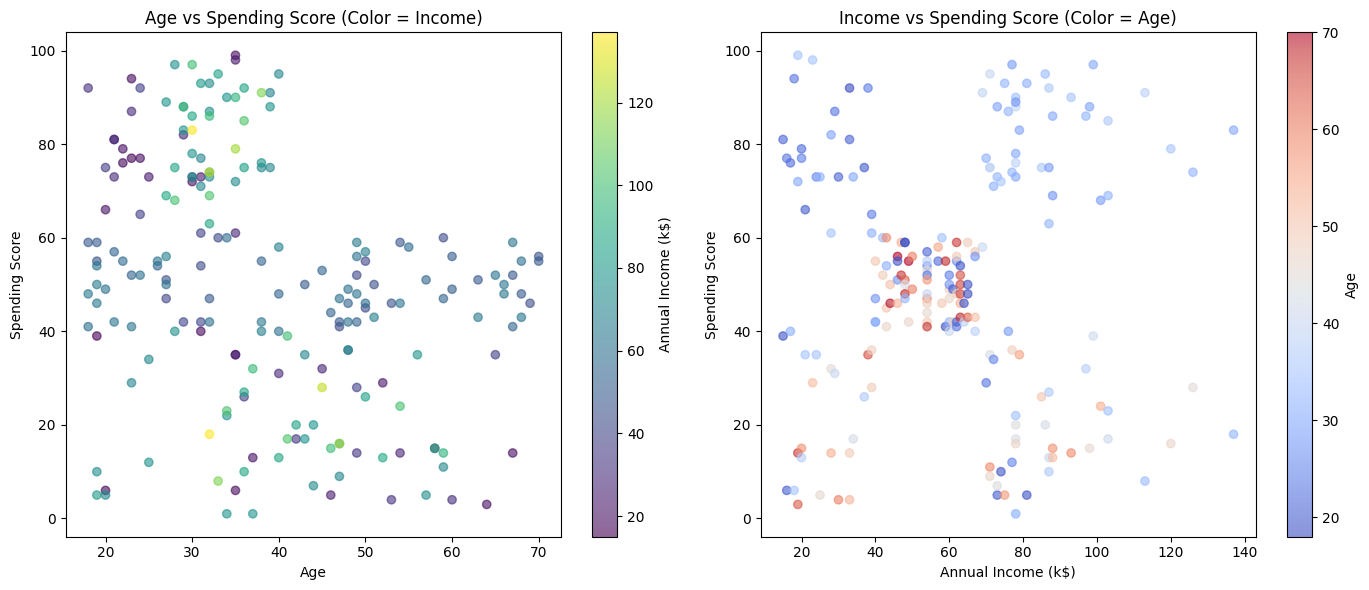

In [34]:

# ============================================================================
# Part 4: Relationships Between Variables
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Age vs Spending Score
scatter1 = axes[0].scatter(customers_df['Age'], customers_df['Spending Score (1-100)'], 
                          c=customers_df['Annual Income (k$)'], cmap='viridis', alpha=0.6)
axes[0].set_title('Age vs Spending Score (Color = Income)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Spending Score')
plt.colorbar(scatter1, ax=axes[0], label='Annual Income (k$)')

# Income vs Spending Score
scatter2 = axes[1].scatter(customers_df['Annual Income (k$)'], customers_df['Spending Score (1-100)'], 
                          c=customers_df['Age'], cmap='coolwarm', alpha=0.6)
axes[1].set_title('Income vs Spending Score (Color = Age)')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score')
plt.colorbar(scatter2, ax=axes[1], label='Age')

plt.tight_layout()
plt.show()


In [35]:

# ============================================================================
# Part 5: Data Preparation for Clustering
# ============================================================================
print("\n" + "="*60)
print("Data Preparation for Clustering")
print("="*60)

# Use Annual Income and Spending Score for clustering
features = customers_df[['Annual Income (k$)', 'Spending Score (1-100)']]
print(f"Data shape for clustering: {features.shape}")

# Scale the data (very important for K-Means)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
print("✓ Data scaling completed successfully")



Data Preparation for Clustering
Data shape for clustering: (200, 2)
✓ Data scaling completed successfully



Determining Optimal Number of Clusters
Elbow Method Results:
K =  1 : Inertia = 400.00
K =  2 : Inertia = 269.69
K =  3 : Inertia = 157.70
K =  4 : Inertia = 108.92
K =  5 : Inertia = 65.57
K =  6 : Inertia = 55.06
K =  7 : Inertia = 44.86
K =  8 : Inertia = 37.23
K =  9 : Inertia = 32.39
K = 10 : Inertia = 29.98

Silhouette Score Results:
K =  2 : Silhouette Score = 0.321
K =  3 : Silhouette Score = 0.467
K =  4 : Silhouette Score = 0.494
K =  5 : Silhouette Score = 0.555
K =  6 : Silhouette Score = 0.540
K =  7 : Silhouette Score = 0.528
K =  8 : Silhouette Score = 0.455
K =  9 : Silhouette Score = 0.457
K = 10 : Silhouette Score = 0.443


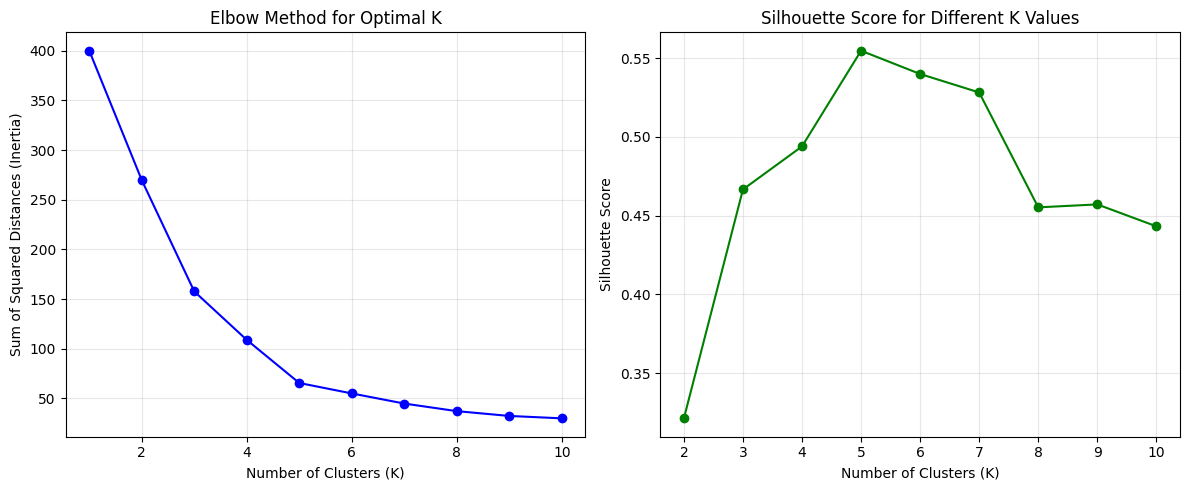


✓ Based on Elbow Method and Silhouette Score, optimal K = 5


In [36]:

# ============================================================================
# Part 6: Determining Optimal Number of Clusters
# ============================================================================
print("\n" + "="*60)
print("Determining Optimal Number of Clusters")
print("="*60)

# Method 1: Elbow Method
print("Elbow Method Results:")
inertia_values = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia_values.append(kmeans.inertia_)
    print(f"K = {k:2d} : Inertia = {kmeans.inertia_:.2f}")

# Plot Elbow Curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia_values, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Distances (Inertia)')
plt.title('Elbow Method for Optimal K')
plt.grid(True, alpha=0.3)

# Method 2: Silhouette Score
print("\nSilhouette Score Results:")
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(scaled_features)
    silhouette_avg = silhouette_score(scaled_features, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"K = {k:2d} : Silhouette Score = {silhouette_avg:.3f}")

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, 'go-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Select optimal K
optimal_k = 5
print(f"\n✓ Based on Elbow Method and Silhouette Score, optimal K = {optimal_k}")


In [37]:

# ============================================================================
# Part 7: Applying K-Means Algorithm
# ============================================================================
print("\n" + "="*60)
print("Applying K-Means Algorithm")
print("="*60)

# Create and train K-Means model
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
customers_df['Cluster'] = kmeans_model.fit_predict(scaled_features)

# Get cluster centers in original scale
cluster_centers_scaled = kmeans_model.cluster_centers_
cluster_centers_original = scaler.inverse_transform(cluster_centers_scaled)

print("✓ K-Means applied successfully")
print(f"\nCluster Centers (Original Scale):")
for i, center in enumerate(cluster_centers_original):
    print(f"Cluster {i}: Income = {center[0]:.1f}k$, Spending = {center[1]:.1f}")



Applying K-Means Algorithm
✓ K-Means applied successfully

Cluster Centers (Original Scale):
Cluster 0: Income = 55.3k$, Spending = 49.5
Cluster 1: Income = 86.5k$, Spending = 82.1
Cluster 2: Income = 25.7k$, Spending = 79.4
Cluster 3: Income = 88.2k$, Spending = 17.1
Cluster 4: Income = 26.3k$, Spending = 20.9


In [38]:

# ============================================================================
# Part 8: Segment Analysis and Labeling
# ============================================================================
print("\n" + "="*60)
print("Segment Analysis and Labeling")
print("="*60)

# Analyze each cluster
cluster_stats = customers_df.groupby('Cluster').agg({
    'Annual Income (k$)': ['mean', 'std', 'min', 'max'],
    'Spending Score (1-100)': ['mean', 'std', 'min', 'max'],
    'Age': 'mean',
    'Gender': lambda x: (x.value_counts() / len(x) * 100).to_dict()
}).round(2)

print("Detailed Statistics for Each Cluster:")
print(cluster_stats)

# Label segments based on characteristics
segment_labels = {
    0: 'Budget Shoppers',
    1: 'Premium Buyers', 
    2: 'Moderate Spenders',
    3: 'Wealthy Cautious',
    4: 'Average Consumers'
}

customers_df['Segment'] = customers_df['Cluster'].map(segment_labels)

# Segment distribution
segment_distribution = customers_df['Segment'].value_counts()
print("\n Customer Segment Distribution:")
for segment, count in segment_distribution.items():
    percentage = (count / len(customers_df)) * 100
    print(f"  {segment}: {count} customers ({percentage:.1f}%)")



Segment Analysis and Labeling
Detailed Statistics for Each Cluster:
        Annual Income (k$)                 Spending Score (1-100)             \
                      mean    std min  max                   mean    std min   
Cluster                                                                        
0                    55.30   8.99  39   76                  49.52   6.53  34   
1                    86.54  16.31  69  137                  82.13   9.36  63   
2                    25.73   7.57  15   39                  79.36  10.50  61   
3                    88.20  16.40  70  137                  17.11   9.95   1   
4                    26.30   7.89  15   39                  20.91  13.02   3   

               Age                                             Gender  
        max   mean                                           <lambda>  
Cluster                                                                
0        61  42.72  {'Female': 59.25925925925925, 'Male': 40.74074...  
1 

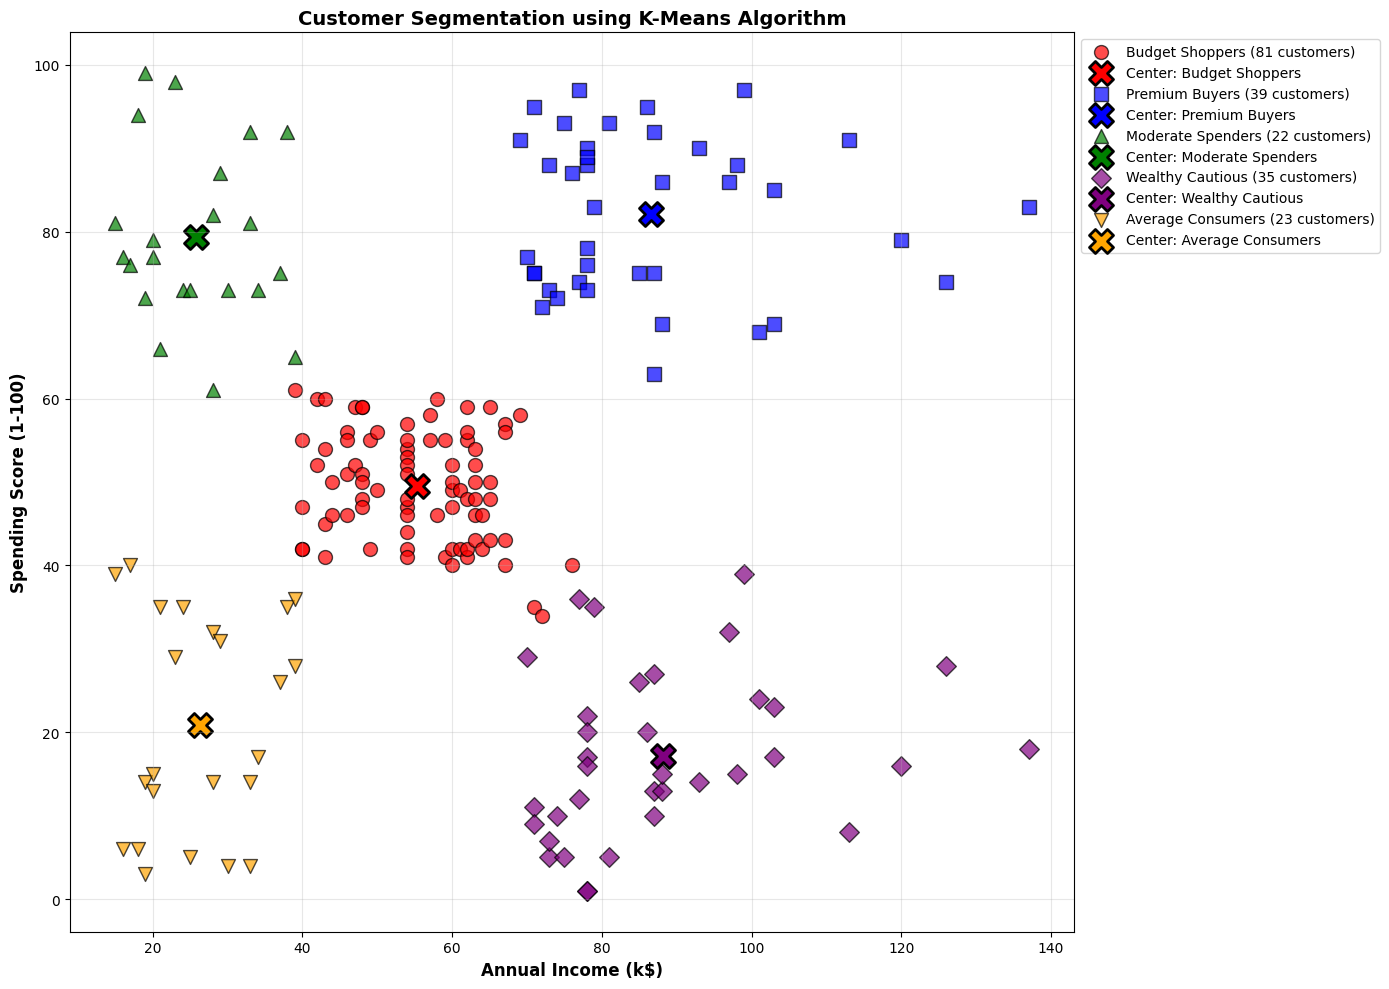

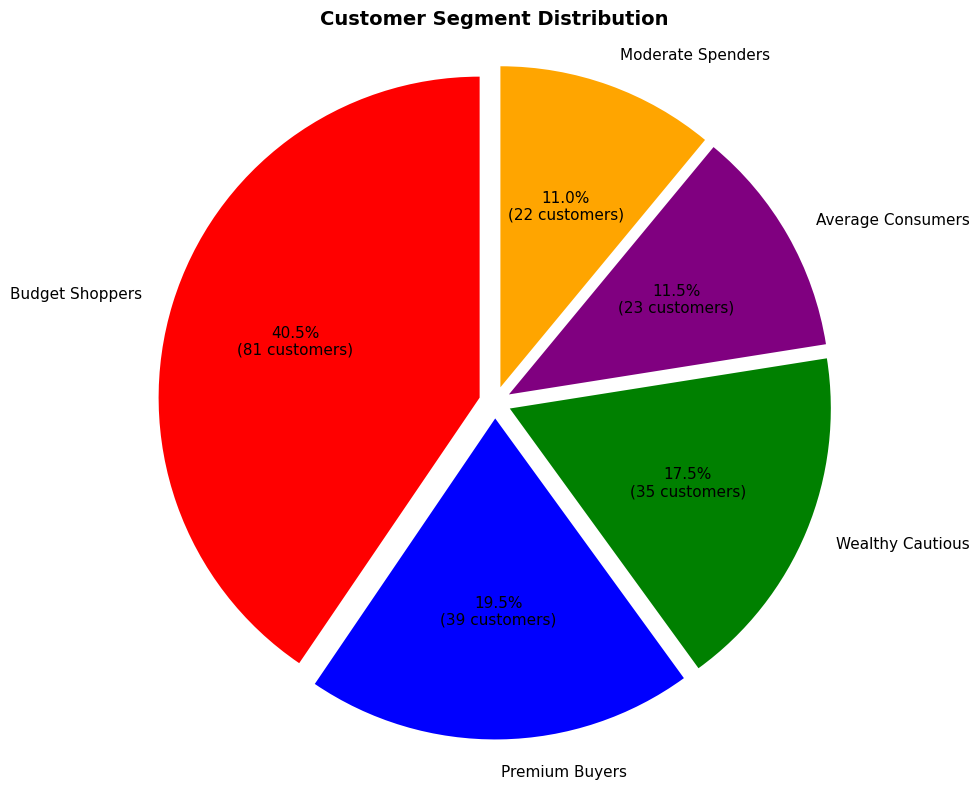

In [39]:

# ============================================================================
# Part 9: Visualizing the Segments
# ============================================================================
plt.figure(figsize=(14, 10))

# Plot segments with different colors
colors = ['red', 'blue', 'green', 'purple', 'orange']
markers = ['o', 's', '^', 'D', 'v']

for cluster_num in range(optimal_k):
    # Cluster data
    cluster_data = customers_df[customers_df['Cluster'] == cluster_num]
    
    # Plot cluster points
    plt.scatter(
        cluster_data['Annual Income (k$)'],
        cluster_data['Spending Score (1-100)'],
        c=colors[cluster_num],
        marker=markers[cluster_num],
        label=f'{segment_labels[cluster_num]} ({len(cluster_data)} customers)',
        s=100,
        alpha=0.7,
        edgecolors='black',
        linewidth=1
    )
    
    # Plot cluster center
    center = cluster_centers_original[cluster_num]
    plt.scatter(
        center[0],
        center[1],
        c=colors[cluster_num],
        marker='X',
        s=300,
        edgecolors='black',
        linewidth=2,
        label=f'Center: {segment_labels[cluster_num]}'
    )

# Formatting
plt.xlabel('Annual Income (k$)', fontsize=12, fontweight='bold')
plt.ylabel('Spending Score (1-100)', fontsize=12, fontweight='bold')
plt.title('Customer Segmentation using K-Means Algorithm', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Pie chart for segment distribution
plt.figure(figsize=(10, 8))
plt.pie(
    segment_distribution.values,
    labels=segment_distribution.index,
    colors=colors[:optimal_k],
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*len(customers_df))} customers)',
    startangle=90,
    explode=[0.05] * optimal_k,
    textprops={'fontsize': 11}
)
plt.title('Customer Segment Distribution', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()


In [40]:

# ============================================================================
# Part 10: Detailed Segment Analysis
# ============================================================================
print("\n" + "="*60)
print("Detailed Segment Analysis")
print("="*60)

detailed_analysis = []

for segment_name in segment_labels.values():
    segment_data = customers_df[customers_df['Segment'] == segment_name]
    
    # Demographic analysis
    avg_age = segment_data['Age'].mean()
    gender_dist = segment_data['Gender'].value_counts(normalize=True) * 100
    
    # Economic analysis
    avg_income = segment_data['Annual Income (k$)'].mean()
    avg_spending = segment_data['Spending Score (1-100)'].mean()
    
    # Calculate attractiveness index
    attractiveness_index = (avg_income * avg_spending) / 100
    
    analysis = {
        'Segment': segment_name,
        'Customer Count': len(segment_data),
        'Percentage': f"{(len(segment_data)/len(customers_df)*100):.1f}%",
        'Average Age': f"{avg_age:.1f} years",
        'Male Percentage': f"{gender_dist.get('Male', 0):.1f}%",
        'Female Percentage': f"{gender_dist.get('Female', 0):.1f}%",
        'Average Income': f"{avg_income:.0f} k$",
        'Average Spending': f"{avg_spending:.1f}",
        'Attractiveness Index': f"{attractiveness_index:.1f}"
    }
    
    detailed_analysis.append(analysis)

# Display results in table
analysis_df = pd.DataFrame(detailed_analysis)
print(" Detailed Segment Analysis:")
print(analysis_df.to_string(index=False))



Detailed Segment Analysis
 Detailed Segment Analysis:
          Segment  Customer Count Percentage Average Age Male Percentage Female Percentage Average Income Average Spending Attractiveness Index
  Budget Shoppers              81      40.5%  42.7 years           40.7%             59.3%          55 k$             49.5                 27.4
   Premium Buyers              39      19.5%  32.7 years           46.2%             53.8%          87 k$             82.1                 71.1
Moderate Spenders              22      11.0%  25.3 years           40.9%             59.1%          26 k$             79.4                 20.4
 Wealthy Cautious              35      17.5%  41.1 years           54.3%             45.7%          88 k$             17.1                 15.1
Average Consumers              23      11.5%  45.2 years           39.1%             60.9%          26 k$             20.9                  5.5


In [41]:

# ============================================================================
# Part 11: Marketing Strategies for Each Segment
# ============================================================================
print("\n" + "="*60)
print("Personalized Marketing Strategies")
print("="*60)

marketing_strategies = {
    'Premium Buyers': {
        'Segment Profile': 'High income, high spending, high attractiveness',
        'Strategy': 'Premium Luxury Marketing',
        'Goals': 'Increase loyalty, enhance luxury brand image',
        'Tactics': [
            'Exclusive VIP offers',
            'Luxury and high-quality products',
            '24/7 personalized customer service',
            'Invitations to product launch parties',
            'Premium loyalty programs'
        ],
        'Communication Channels': ['Luxury direct mail', 'Personal invitations', 'Public relations'],
        'Budget': 'High',
        'Success Metric': 'Customer retention rate > 90%'
    },
    
    'Moderate Spenders': {
        'Segment Profile': 'Medium income, medium spending, medium attractiveness',
        'Strategy': 'Value and Quality Marketing',
        'Goals': 'Increase purchase frequency, diversify purchases',
        'Tactics': [
            'Excellent value offers',
            'Discounts on repeat purchases',
            'Rewards programs',
            'Reminders of previous purchases',
            'Bundle offers'
        ],
        'Communication Channels': ['Email', 'Social media', 'Mobile apps'],
        'Budget': 'Medium',
        'Success Metric': 'Increase frequency by 20%'
    },
    
    'Budget Shoppers': {
        'Segment Profile': 'Low income, low spending, low attractiveness',
        'Strategy': 'Price and Competitive Marketing',
        'Goals': 'Increase purchase volume, attract with price advantages',
        'Tactics': [
            'Big discount offers',
            'Economical products',
            'Quantity discounts',
            'Competitive pricing',
            'Deferred payment offers'
        ],
        'Communication Channels': ['Competitive advertising', 'Promotional leaflets', 'Billboards'],
        'Budget': 'Low',
        'Success Metric': 'Increase basket size by 15%'
    },
    
    'Wealthy Cautious': {
        'Segment Profile': 'High income, low spending, medium attractiveness',
        'Strategy': 'Trust and Quality Marketing',
        'Goals': 'Increase spending, build trust',
        'Tactics': [
            'Focus on quality and durability',
            'Extended warranty offers',
            'Free trials',
            'Testimonials from successful customers',
            'Detailed product information'
        ],
        'Communication Channels': ['Educational content', 'Customer testimonials', 'Specialized exhibitions'],
        'Budget': 'Medium to High',
        'Success Metric': 'Increase spending by 25%'
    },
    
    'Average Consumers': {
        'Segment Profile': 'Medium income, medium to high spending, medium attractiveness',
        'Strategy': 'Diversity and Convenience Marketing',
        'Goals': 'Increase loyalty, improve customer experience',
        'Tactics': [
            'Medium-priced offers',
            'Seasonal discounts',
            'Basic loyalty programs',
            'Fast delivery service',
            'Diverse products'
        ],
        'Communication Channels': ['General advertising', 'Email marketing', 'Content marketing'],
        'Budget': 'Medium',
        'Success Metric': 'Repeat purchase rate > 60%'
    }
}

# Display strategies
for segment, strategy in marketing_strategies.items():
    print(f"\n **Segment: {segment}**")
    print(f" {strategy['Segment Profile']}")
    print(f"**Strategy:** {strategy['Strategy']}")
    print(f" **Goals:** {strategy['Goals']}")
    print(" **Proposed Tactics:**")
    for i, tactic in enumerate(strategy['Tactics'], 1):
        print(f"   {i}. {tactic}")
    print(f" **Communication Channels:** {', '.join(strategy['Communication Channels'])}")
    print(f" **Suggested Budget:** {strategy['Budget']}")
    print(f" **Success Metric:** {strategy['Success Metric']}")
    print("-" * 60)



Personalized Marketing Strategies

 **Segment: Premium Buyers**
 High income, high spending, high attractiveness
**Strategy:** Premium Luxury Marketing
 **Goals:** Increase loyalty, enhance luxury brand image
 **Proposed Tactics:**
   1. Exclusive VIP offers
   2. Luxury and high-quality products
   3. 24/7 personalized customer service
   4. Invitations to product launch parties
   5. Premium loyalty programs
 **Communication Channels:** Luxury direct mail, Personal invitations, Public relations
 **Suggested Budget:** High
 **Success Metric:** Customer retention rate > 90%
------------------------------------------------------------

 **Segment: Moderate Spenders**
 Medium income, medium spending, medium attractiveness
**Strategy:** Value and Quality Marketing
 **Goals:** Increase purchase frequency, diversify purchases
 **Proposed Tactics:**
   1. Excellent value offers
   2. Discounts on repeat purchases
   3. Rewards programs
   4. Reminders of previous purchases
   5. Bundle offe

In [42]:

# ============================================================================
# Part 12: Model Quality Evaluation
# ============================================================================
print("\n" + "="*60)
print("Segmentation Quality Evaluation")
print("="*60)

# Calculate Silhouette Score
silhouette_avg = silhouette_score(scaled_features, customers_df['Cluster'])
print(f" Silhouette Score: {silhouette_avg:.3f}")

if silhouette_avg > 0.7:
    quality = "Excellent"
elif silhouette_avg > 0.5:
    quality = "Good"
elif silhouette_avg > 0.25:
    quality = "Acceptable"
else:
    quality = "Poor"

print(f"   → Segmentation Quality: {quality}")

# Calculate explained variance ratio
total_variance = np.var(scaled_features, axis=0).sum()
within_cluster_variance = kmeans_model.inertia_
between_cluster_variance = total_variance - within_cluster_variance
explained_variance_ratio = between_cluster_variance / total_variance

print(f"\n Explained Variance Ratio: {explained_variance_ratio:.1%}")
print("   (Percentage of variance explained by the clusters)")



Segmentation Quality Evaluation
 Silhouette Score: 0.555
   → Segmentation Quality: Good

 Explained Variance Ratio: -3178.4%
   (Percentage of variance explained by the clusters)


In [43]:

# ============================================================================
# Part 13: Prediction Model for New Customers
# ============================================================================
print("\n" + "="*60)
print("New Customer Prediction Model")
print("="*60)

def predict_customer_segment(annual_income, spending_score, age=None, gender=None):
    """
    Predict segment for a new customer
    
    Parameters:
    annual_income (float): Annual income in thousand dollars
    spending_score (int): Spending score from 1 to 100
    age (int): Age (optional)
    gender (str): Gender (optional)
    
    Returns:
    dict: Information about predicted segment
    """
    # Prepare customer data
    customer_features = np.array([[annual_income, spending_score]])
    
    # Scale data using same scaler as training
    customer_scaled = scaler.transform(customer_features)
    
    # Predict cluster
    predicted_cluster = kmeans_model.predict(customer_scaled)[0]
    segment_name = segment_labels[predicted_cluster]
    
    # Segment information
    segment_info = analysis_df[analysis_df['Segment'] == segment_name].iloc[0]
    strategy = marketing_strategies[segment_name]
    
    return {
        'Segment': segment_name,
        'Cluster_Number': int(predicted_cluster),
        'Segment_Avg_Income': segment_info['Average Income'],
        'Segment_Avg_Spending': segment_info['Average Spending'],
        'Segment_Percentage': segment_info['Percentage'],
        'Recommended_Strategy': strategy['Strategy'],
        'Primary_Tactic': strategy['Tactics'][0],
        'Quick_Advice': f"Focus on {strategy['Goals'].split(',')[0]}"
    }

# Test the prediction model
print(" Prediction Model Testing:")
print("-" * 50)

test_customers = [
    {'name': 'New Customer 1', 'income': 15, 'spending': 90, 'age': 22, 'gender': 'Female'},
    {'name': 'New Customer 2', 'income': 85, 'spending': 15, 'age': 48, 'gender': 'Male'},
    {'name': 'New Customer 3', 'income': 45, 'spending': 65, 'age': 32, 'gender': 'Female'},
    {'name': 'New Customer 4', 'income': 120, 'spending': 85, 'age': 40, 'gender': 'Male'},
    {'name': 'New Customer 5', 'income': 30, 'spending': 40, 'age': 28, 'gender': 'Female'},
]

for test in test_customers:
    prediction = predict_customer_segment(
        test['income'],
        test['spending'],
        test['age'],
        test['gender']
    )
    
    print(f"\n {test['name']}:")
    print(f"    Data: {test['age']} years, {test['gender']}")
    print(f"    Income: ${test['income']}k, Spending: {test['spending']}")
    print(f"    Predicted Segment: {prediction['Segment']}")
    print(f"    Compared to Segment Average:")
    print(f"      - Avg Income: {prediction['Segment_Avg_Income']}")
    print(f"      - Avg Spending: {prediction['Segment_Avg_Spending']}")
    print(f"    Recommendation: {prediction['Quick_Advice']}")
    print("-" * 40)



New Customer Prediction Model
 Prediction Model Testing:
--------------------------------------------------

 New Customer 1:
    Data: 22 years, Female
    Income: $15k, Spending: 90
    Predicted Segment: Moderate Spenders
    Compared to Segment Average:
      - Avg Income: 26 k$
      - Avg Spending: 79.4
    Recommendation: Focus on Increase purchase frequency
----------------------------------------

 New Customer 2:
    Data: 48 years, Male
    Income: $85k, Spending: 15
    Predicted Segment: Wealthy Cautious
    Compared to Segment Average:
      - Avg Income: 88 k$
      - Avg Spending: 17.1
    Recommendation: Focus on Increase spending
----------------------------------------

 New Customer 3:
    Data: 32 years, Female
    Income: $45k, Spending: 65
    Predicted Segment: Budget Shoppers
    Compared to Segment Average:
      - Avg Income: 55 k$
      - Avg Spending: 49.5
    Recommendation: Focus on Increase purchase volume
----------------------------------------

 New 

In [44]:

# ============================================================================
# Part 14: Save Results and Reports
# ============================================================================
print("\n" + "="*60)
print("Saving Results and Reports")
print("="*60)

# Save data with segmentation
customers_df.to_csv('customers_with_segments.csv', index=False, encoding='utf-8-sig')
print("✓ Customer data with segments saved to: customers_with_segments.csv")

# Save segment analysis
analysis_df.to_csv('segments_analysis.csv', index=False, encoding='utf-8-sig')
print("✓ Segment analysis saved to: segments_analysis.csv")

# Create summary report
from datetime import datetime

with open('segmentation_report.txt', 'w', encoding='utf-8') as f:
    f.write("="*60 + "\n")
    f.write("Customer Segmentation Project Report using K-Means\n")
    f.write("="*60 + "\n\n")
    
    f.write(f" Report Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")
    f.write(f" Total Customers: {len(customers_df)}\n")
    f.write(f" Number of Segments: {optimal_k}\n")
    f.write(f" Segmentation Quality (Silhouette Score): {silhouette_avg:.3f} ({quality})\n")
    f.write(f" Explained Variance Ratio: {explained_variance_ratio:.1%}\n\n")
    
    f.write(" Segment Distribution:\n")
    for segment, count in segment_distribution.items():
        percentage = (count / len(customers_df)) * 100
        f.write(f"  • {segment}: {count} customers ({percentage:.1f}%)\n")
    
    f.write("\n Marketing Strategies Summary:\n")
    for segment in segment_labels.values():
        f.write(f"\n  • {segment}:\n")
        f.write(f"    Strategy: {marketing_strategies[segment]['Strategy']}\n")
        f.write(f"    Primary Tactic: {marketing_strategies[segment]['Tactics'][0]}\n")

print("✓ Project report saved to: segmentation_report.txt")



Saving Results and Reports
✓ Customer data with segments saved to: customers_with_segments.csv
✓ Segment analysis saved to: segments_analysis.csv
✓ Project report saved to: segmentation_report.txt


In [45]:
# ============================================================================
# Part 15: Project Summary
# ============================================================================

print("\n" + "="*60)
print("Project Summary")
print("="*60)

print(f"""
 **Project Successfully Completed with:**

1. **Data Loading and Analysis** - Understanding customer characteristics
2. **Data Cleaning and Preparation** - Scaling data for clustering
3. **Optimal K Determination** - Using Elbow Method and Silhouette Score
4. **K-Means Application** - Segmenting customers into {optimal_k} clusters
5. **Segment Labeling** - Based on each cluster's characteristics
6. **Detailed Analysis** - Demographic and economic analysis of each segment
7. **Marketing Strategies** - Customized planning for each segment
8. **Model Evaluation** - Measuring segmentation quality
9. **Prediction Model** - For new customers
10. **Comprehensive Report** - Documenting results and recommendations

 **Key Results:**
• {optimal_k} distinct customer segments with unique characteristics
• Customized marketing strategies for each segment
• Ready-to-use prediction model
• {quality} segmentation quality (Silhouette = {silhouette_avg:.3f})

 **Practical Applications:**
1. Customized advertising campaigns
2. Targeted offer design
3. Improved customer experience
4. Increased sales and profitability
5. Data-driven marketing decisions
""")

print(f"\n **Generated Files:**")
print("1. customers_with_segments.csv - Customer data with segmentation")
print("2. segments_analysis.csv - Detailed segment analysis")
print("3. segmentation_report.txt - Complete project report")

print("\n" + "="*60)
print(" Customer Segmentation Project Successfully Completed!")
print("="*60)


Project Summary

 **Project Successfully Completed with:**

1. **Data Loading and Analysis** - Understanding customer characteristics
2. **Data Cleaning and Preparation** - Scaling data for clustering
3. **Optimal K Determination** - Using Elbow Method and Silhouette Score
4. **K-Means Application** - Segmenting customers into 5 clusters
5. **Segment Labeling** - Based on each cluster's characteristics
6. **Detailed Analysis** - Demographic and economic analysis of each segment
7. **Marketing Strategies** - Customized planning for each segment
8. **Model Evaluation** - Measuring segmentation quality
9. **Prediction Model** - For new customers
10. **Comprehensive Report** - Documenting results and recommendations

 **Key Results:**
• 5 distinct customer segments with unique characteristics
• Customized marketing strategies for each segment
• Ready-to-use prediction model
• Good segmentation quality (Silhouette = 0.555)

 **Practical Applications:**
1. Customized advertising campaigns
2